## **Integrate Apartment Data**

### **Load GWR (include kitchen data)**

In [1]:
import pandas as pd
# load the csv file into a DataFrame
df_apartment = pd.read_csv(r'D:/Github/Data/ch_apartment_kitchen.txt', sep='\t')
# len(df_kitchen) # 5111766

C:\Users\xiong\AppData\Local\Temp\ipykernel_14264\3651102663.py:3: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_apartment = pd.read_csv(r'D:/Github/Data/ch_apartment_kitchen.txt', sep='\t')


### *Apartment data to connect with calculation first*

In [3]:
from HVAC import calculate_radiators_per_apartment
from HVAC import calculate_HVAC_pipe_length_per_apartment
from plumbing import calculate_water_pipe_length_per_apartment
from plumbing import calculate_num_bathroom
from electrical import calculate_electrical_cable_length_per_apartment
# from electrical import calculate_electrical_cable_length_per_building

In [ ]:
# # remove the rows with NaN values in the column 'WAZIM','WKCHE','WAREA'
# df_apartment = df_apartment.dropna(subset=['WAZIM','WKCHE','WAREA'])
# len(df_apartment) # 4955689

4955689

In [4]:
for index, row in df_apartment.iterrows():
  
    # check if 'WAZIM','WKCHE','WAREA' is empty or null
    if pd.isna(row['WAZIM']) or pd.isna(row['WKCHE']) or pd.isna(row['WAREA']):
        df_apartment.loc[index, ['number of radiators', 'air duct length', 'water pipe length', 'number of toilets', 'number of sink', 'number of shower', 'number of bathtub', 'electrical cable length']] = pd.NA
        continue

    # Residential Building
    num_rooms_per_apartment = row['WAZIM']
    num_kitchen_per_apartment = row['WKCHE']
    living_space_per_apartment = row['WAREA']

    # @ radiator    
    num_radiators_per_apartment=calculate_radiators_per_apartment(living_space_per_apartment,num_rooms_per_apartment,num_kitchen_per_apartment)
    df_apartment.loc[index, 'number of radiators'] = num_radiators_per_apartment

    # @ air ducts
    HVAC_pipe_length_per_apartment = calculate_HVAC_pipe_length_per_apartment(living_space_per_apartment, num_rooms_per_apartment)
    df_apartment.loc[index, 'air duct length'] = HVAC_pipe_length_per_apartment

    # @ water pipes
    water_pipe_length = calculate_water_pipe_length_per_apartment(num_rooms_per_apartment, num_kitchen_per_apartment,living_space_per_apartment)
    df_apartment.loc[index, 'water pipe length'] = water_pipe_length
    
    # @ plumbing fixtures
    # assuming 1 toilet, 1 shower, 1 sink, 1 bathtub per bathroom
    num_bathrooms = calculate_num_bathroom(num_rooms_per_apartment)
    plumbing_fixtures = ['toilets', 'sink', 'shower', 'bathtub']
    for fixture in plumbing_fixtures:
        df_apartment.loc[index,'number of ' + fixture] = num_bathrooms
        
    # @ electrical wires
    electrical_wire_length = calculate_electrical_cable_length_per_apartment(living_space_per_apartment,num_rooms_per_apartment)
    df_apartment.loc[index,'electrical cable length'] = electrical_wire_length

df_apartment

,EGID,EWID,EDID,WHGNR,WEINR,WSTWK,WBEZ,WMEHRG,WBAUJ,WABBJ,...,WKCHE,WEXPDAT,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length
0,1,1,0,1,NaN,3100.0,NaN,1.0,1999.0,NaN,...,1.0,2023-04-20,3.0,3.162278,18.973666,0.0,0.0,0.0,0.0,79.056942
1,1,3,0,101,NaN,3101.0,NaN,0.0,1999.0,NaN,...,1.0,2023-04-20,7.0,21.908902,65.726707,2.0,2.0,2.0,2.0,547.722558
2,2,1,0,NaN,NaN,3100.0,NaN,1.0,1999.0,2010.0,...,1.0,2023-04-20,7.0,27.386128,76.681158,2.0,2.0,2.0,2.0,684.653197
3,3,1,0,NaN,NaN,3100.0,NaN,1.0,1999.0,NaN,...,1.0,2023-04-20,8.0,36.000000,96.000000,3.0,3.0,3.0,3.0,900.000000
4,4,1,0,NaN,NaN,3100.0,NaN,1.0,1999.0,NaN,...,1.0,2023-04-20,9.0,31.622777,88.543774,2.0,2.0,2.0,2.0,790.569415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5111761,504150050,1,0,NaN,NaN,3100.0,NaN,0.0,1999.0,NaN,...,1.0,2023-04-20,4.0,10.283482,34.278273,1.0,1.0,1.0,1.0,257.087048
5111762,504150051,1,0,NaN,NaN,3100.0,NaN,0.0,1999.0,NaN,...,1.0,2023-04-20,3.0,3.535534,21.213203,0.0,0.0,0.0,0.0,88.388348
5111763,504150060,1,0,NaN,NaN,3101.0,NaN,0.0,1999.0,NaN,...,1.0,2023-04-20,2.0,2.645751,15.874508,0.0,0.0,0.0,0.0,66.143783
5111764,504150092,1,0,NaN,NaN,3100.0,NaN,0.0,1999.0,NaN,...,1.0,2023-04-20,2.0,1.936492,11.618950,0.0,0.0,0.0,0.0,48.412292


In [5]:
df_apartment.to_csv('df_apartment_with_component_estimation.txt', index=False)

## *load apartment data with calculated data*

In [ ]:
import pandas as pd
# load the txt file into a DataFrame
df_apartment = pd.read_csv(r'D:/Github/Data/df_apartment_with_component_estimation.txt') # this includes all the buildings of 1873819

# Define columns to sum
columns_to_sum = [
    'WAREA','WAZIM','WKCHE',
    'number of radiators',
    'air duct length',
    'water pipe length',
    'number of toilets',
    'number of sink',
    'number of shower',
    'number of bathtub',
    'electrical cable length'
]

# Define first-value columns (columns that should keep the first value per group)
# These would be all other columns except EGID and columns_to_sum
other_columns = [col for col in df_apartment.columns if col not in columns_to_sum + ['EGID']]

# Create the aggregation dictionary
agg_dict = {
    **{col: 'sum' for col in columns_to_sum},
    **{col: 'first' for col in other_columns}
}

# Perform the groupby with different aggregations per column
df_apartment_agg = df_apartment.groupby('EGID').agg(agg_dict).reset_index()

# df_apartment_agg = df_apartment.groupby(['EGID']).sum().reset_index() # this only includes the residential buildings of 1873819
df_building = pd.read_csv(r'D:/Github/Data/ch_building_renovation.txt', sep='\t') # this includes all the buildings of 3167273

C:\Users\xiong\AppData\Local\Temp\ipykernel_14264\2501661755.py:3: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_apartment = pd.read_csv('df_apartment_with_component_estimation.txt') # this includes all the buildings of 1873819
C:\Users\xiong\AppData\Local\Temp\ipykernel_14264\2501661755.py:32: DtypeWarning: Columns (6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_building = pd.read_csv(r'D:/Github/Data/ch_building_renovation.txt', sep='\t') # this includes all the buildings of 3167273


In [18]:
# Show all columns (temporarily)
pd.set_option('display.max_columns', None)  # Show all columns
# remove columns
columns_to_remove = ['WHGNR', 'WEINR', 'WBEZ', 'WEXPDAT']
df_apartment_agg = df_apartment_agg.drop(columns=columns_to_remove)
df_apartment_agg

,EGID,WAREA,WAZIM,WKCHE,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length,EWID,EDID,WSTWK,WMEHRG,WBAUJ,WABBJ,WSTAT
0,1,160.0,5.0,2.0,10.0,25.071180,84.700373,2.0,2.0,2.0,2.0,626.779499,1,0,3100.0,1.0,1999.0,NaN,3004.0
1,2,120.0,5.0,1.0,7.0,27.386128,76.681158,2.0,2.0,2.0,2.0,684.653197,1,0,3100.0,1.0,1999.0,2010.0,3007.0
2,3,144.0,6.0,1.0,8.0,36.000000,96.000000,3.0,3.0,3.0,3.0,900.000000,1,0,3100.0,1.0,1999.0,NaN,3004.0
3,4,160.0,5.0,1.0,9.0,31.622777,88.543774,2.0,2.0,2.0,2.0,790.569415,1,0,3100.0,1.0,1999.0,NaN,3004.0
4,5,120.0,4.0,1.0,7.0,21.908902,65.726707,2.0,2.0,2.0,2.0,547.722558,1,0,3100.0,1.0,1999.0,NaN,3004.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873814,504150050,47.0,3.0,1.0,4.0,10.283482,34.278273,1.0,1.0,1.0,1.0,257.087048,1,0,3100.0,0.0,1999.0,NaN,3004.0
1873815,504150051,50.0,1.0,1.0,3.0,3.535534,21.213203,0.0,0.0,0.0,0.0,88.388348,1,0,3100.0,0.0,1999.0,NaN,3004.0
1873816,504150060,28.0,1.0,1.0,2.0,2.645751,15.874508,0.0,0.0,0.0,0.0,66.143783,1,0,3101.0,0.0,1999.0,NaN,3004.0
1873817,504150092,15.0,1.0,1.0,2.0,1.936492,11.618950,0.0,0.0,0.0,0.0,48.412292,1,0,3100.0,0.0,1999.0,NaN,3004.0


In [19]:
# Later, to reset back to default settings
pd.reset_option('display.max_columns')

#### **Merge Databases of Apartment/Building**

In [20]:
# merge the two DataFrames since building identifier is the same (wohnung are part of the building)
df_apartment_agg_to_building = pd.merge(df_building, df_apartment_agg, on='EGID', how='left') # change to left/inner join if needed
df_apartment_agg_to_building # 3167273

,EGID,GDEKT,GGDENR,GGDENAME,EGRID,LGBKR,LPARZ,LPARZSX,LTYP,GEBNR,...,number of shower,number of bathtub,electrical cable length,EWID,EDID,WSTWK,WMEHRG,WBAUJ,WABBJ,WSTAT
0,11513432,ZH,1,Aeugst am Albis,CH540120777857,0.0,1573.0,NaN,NaN,1199,...,4.0,4.0,1092.302393,1.0,0.0,3102.0,0.0,2000.0,NaN,3004.0
1,11513433,ZH,1,Aeugst am Albis,CH587820017717,0.0,1543.0,NaN,NaN,1198,...,2.0,2.0,570.087713,1.0,0.0,3100.0,1.0,2000.0,NaN,3004.0
2,11517090,ZH,1,Aeugst am Albis,CH707701872012,0.0,1361.0,NaN,NaN,1017,...,3.0,3.0,1060.660172,1.0,0.0,3100.0,1.0,1999.0,NaN,3004.0
3,1600000,ZH,1,Aeugst am Albis,CH487820017751,0.0,1631.0,NaN,NaN,164,...,7.0,7.0,2721.831570,3.0,0.0,3100.0,1.0,1999.0,1999.0,3004.0
4,1600001,ZH,1,Aeugst am Albis,CH567720017811,0.0,1579.0,NaN,NaN,154,...,2.0,2.0,592.927061,1.0,0.0,3101.0,0.0,1999.0,NaN,3004.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3167268,984011,JU,6811,Damphreux-Lugnez,CH910603447095,6793.0,1499,NaN,NaN,NaN,...,1.0,1.0,290.473751,1.0,0.0,3100.0,0.0,1999.0,NaN,3004.0
3167269,984012,JU,6811,Damphreux-Lugnez,CH170670034409,6793.0,1506,NaN,NaN,NaN,...,2.0,2.0,447.213595,1.0,0.0,3100.0,0.0,1999.0,NaN,3004.0
3167270,984013,JU,6811,Damphreux-Lugnez,CH967044060305,6793.0,1505,NaN,NaN,NaN,...,1.0,1.0,355.756237,1.0,0.0,3100.0,1.0,1999.0,NaN,3004.0
3167271,984014,JU,6811,Damphreux-Lugnez,CH107006034406,6793.0,1509,NaN,NaN,NaN,...,1.0,1.0,335.410197,1.0,0.0,3100.0,1.0,1999.0,NaN,3004.0


In [21]:
print(df_apartment_agg_to_building.columns)

Index(['EGID', 'GDEKT', 'GGDENR', 'GGDENAME', 'EGRID', 'LGBKR', 'LPARZ',
       'LPARZSX', 'LTYP', 'GEBNR', 'GBEZ', 'GKODE', 'GKODN', 'GKSCE', 'GSTAT',
       'GKAT', 'GKLAS', 'GBAUJ', 'GBAUM', 'GBAUP', 'GABBJ', 'GAREA', 'GVOL',
       'GVOLNORM', 'GVOLSCE', 'GASTW', 'GANZWHG', 'GAZZI', 'GSCHUTZR', 'GEBF',
       'GWAERZH1', 'GENH1', 'GWAERSCEH1', 'GWAERDATH1', 'GWAERZH2', 'GENH2',
       'GWAERSCEH2', 'GWAERDATH2', 'GWAERZW1', 'GENW1', 'GWAERSCEW1',
       'GWAERDATW1', 'GWAERZW2', 'GENW2', 'GWAERSCEW2', 'GWAERDATW2',
       'GEXPDAT', 'WAREA', 'WAZIM', 'WKCHE', 'number of radiators',
       'air duct length', 'water pipe length', 'number of toilets',
       'number of sink', 'number of shower', 'number of bathtub',
       'electrical cable length', 'EWID', 'EDID', 'WSTWK', 'WMEHRG', 'WBAUJ',
       'WABBJ', 'WSTAT'],
      dtype='object')


In [22]:
# save the DataFrame to a txt file
df_apartment_agg_to_building.to_csv(r'D:/Github/Data/df_apartment_agg_to_building.txt', index=False)

# Read data

In [ ]:
import pandas as pd
# load the txt file into a DataFrame
df_apartment_agg_to_building = pd.read_csv(r'D:/Github/Data/df_apartment_agg_to_building.txt')

C:\Users\xiong\AppData\Local\Temp\ipykernel_11284\143101033.py:3: DtypeWarning: Columns (6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_apartment_agg_to_building = pd.read_csv('df_apartment_agg_to_building.txt')


In [23]:
# # select only the columns that are needed
# df_code = pd.read_csv('code_names_short.csv')
# # filter the first DataFrame with the "field name" column of the second DataFrame
# df_GWR= df_building.filter(df_code['code'])

# # select only the columns that are needed
# df_code = pd.read_csv('code_names_short.csv',)
# # filter the first DataFrame with the "field name" column of the second DataFrame
# df_GWR_test= df_building.filter(df_code['code'],'number of radiators', 'air duct length',
#        'water pipe length', 'number of toilets', 'number of sink',
#        'number of shower', 'number of bathtub', 'electrical cable length')
# df_GWR_test

# Read the DataFrame containing necessary column names
df_code = pd.read_csv(r'D:/Github/Data/code_names.csv')

# Create a list of column names from the 'code' column in df_code DataFrame
selected_columns = df_code['code'].tolist()
selected_columns.extend(['number of radiators', 'air duct length', 'water pipe length', 'number of toilets', 'number of sink','number of shower', 'number of bathtub', 'electrical cable length'])

# Filter the columns in df_building DataFrame based on the selected_columns list
df_GWR_test = df_apartment_agg_to_building.filter(selected_columns)



In [24]:
# check empty number of rows for each column
df_GWR_test.isnull().sum()


EDID                       1293454
EGID                             0
GABBJ                      3068631
GANZWHG                    1303923
GAREA                        82608
GASTW                      1065267
GAZZI                      3097019
GBAUJ                      1341244
GBAUM                      2836719
GBEZ                       2438552
GDEKT                            0
GEBF                       2985126
GEBNR                      1203916
GENH1                      1054715
GENH2                      2708126
GENW1                       973668
GENW2                      1962722
GGDENR                           0
GKAT                           827
GKLAS                       181027
GKODE                           93
GKODN                           93
GKSCE                           93
GSTAT                            0
GVOL                       3038976
GWAERZH1                   1070335
GWAERZH2                   2708640
GWAERZW1                    973990
GWAERZW2            

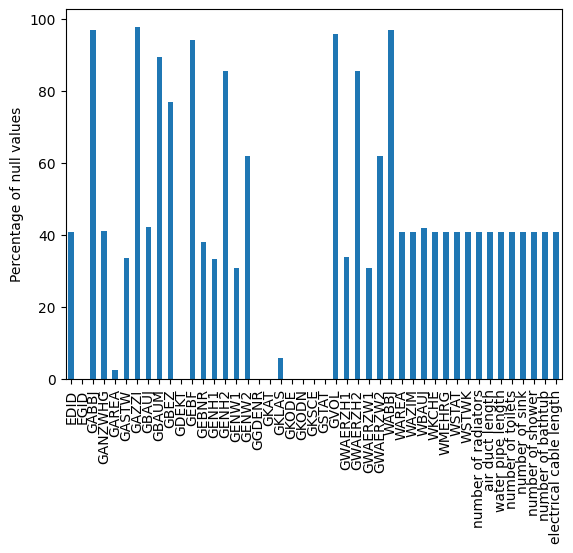

In [25]:
import matplotlib.pyplot as plt

# calculate the percentage of null values in each column
null_percentages = df_GWR_test.isnull().sum() / len(df_GWR_test) * 100

# create a bar chart of the percentage of null values in each column
null_percentages.plot(kind='bar')
plt.ylabel('Percentage of null values')
plt.show()


In [26]:
# remove columns with more than 50% null values
columns_to_drop = null_percentages[null_percentages > 50].index
df_GWR_test_drop = df_GWR_test.drop(columns=columns_to_drop)
# check the remaining columns empty percentage
df_GWR_test_drop.isnull().sum()

EDID                       1293454
EGID                             0
GANZWHG                    1303923
GAREA                        82608
GASTW                      1065267
GBAUJ                      1341244
GDEKT                            0
GEBNR                      1203916
GENH1                      1054715
GENW1                       973668
GGDENR                           0
GKAT                           827
GKLAS                       181027
GKODE                           93
GKODN                           93
GKSCE                           93
GSTAT                            0
GWAERZH1                   1070335
GWAERZW1                    973990
WAREA                      1293454
WAZIM                      1293454
WBAUJ                      1325119
WKCHE                      1293454
WMEHRG                     1295243
WSTAT                      1293454
WSTWK                      1295266
number of radiators        1293454
air duct length            1293454
water pipe length   

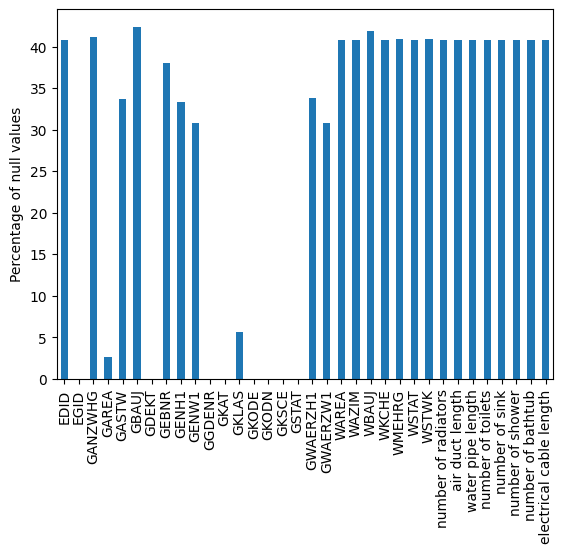

In [27]:
# check the remaining columns empty percentage in bar chart
null_percentages = df_GWR_test_drop.isnull().sum() / len(df_GWR_test_drop) * 100
null_percentages.plot(kind='bar')
plt.ylabel('Percentage of null values')
plt.show()

### **Connecting Old GEAK with New GEAK databases to add EGID number**

In [ ]:
# read file into a DataFrame
df_GEAK_new = pd.read_csv('translated_GEAK.csv')
# split values with delimiter '_' and assign to new columns
df_GEAK_new[['EGID', 'EDID']] = df_GEAK_new['[4a]EGID-EDID'].str.split('_', 1, expand=True)
# drop the original column
df_GEAK_new.drop('[4a]EGID-EDID', axis=1, inplace=True)

# read csv file
df_GEAK = pd.read_csv('GEAK_old.csv')

# select only the columns that are needed
df_GEAK_old = df_GEAK[[
        '[1a]GEAK number (StammN° Kanton-XXXXXXXX + Version .XX)',
        '[1a]Canton)',
        '[1f]Building category',
        '[1h]Year of construction',
        '[2h]Inst./Renov. hot water supply',
        '[2i]Inst./Renov. heating system',
        '[4]EBF total (m2)',
        '[5]Area-related outside air volume flow V/AE',
        '[6]Number of full floors',
        '[7]Construction building',
        '[8]Floor plan type',
        '[9a]Number of residents (EFH/ MFH)',
        'WE1 energy source'
        ]]
# merge on the common column GEAK number and drop the duplicate column
df_GEAK = pd.merge(df_GEAK_old, df_GEAK_new, left_on='[1a]GEAK number (StammN° Kanton-XXXXXXXX + Version .XX)', right_on='[1]GEAK number (root number canton-XXXXXXXX + version .XX)', how='right')


# select only the columns that are needed
df_GEAK = df_GEAK.loc[:, [
'EGID',  
'EDID',    
'[1]GEAK number (root number canton-XXXXXXXX + version .XX)',
'[1h]Year of construction',
'[2h]Inst./Renov. hot water supply',
'[2i]Inst./Renov. heating system',
'[5]Area-related outside air volume flow V/AE',
'[9a]Number of residents (EFH/ MFH)',
'[6a]Building category',
'[7]Year of manufacture',
'[8b]Previous heating consumption [kWh/a]',
'[9a]EBF Total (m2)',
'[9d]Number of apartments',
'[10a]Efficiency of building envelope (A, B,... to G)',
'[10aa]Efficiency of building envelope in kWh/m2/a',
'[11a]Efficiency total energy (A, B,... to G)',
'[11aa]Efficiency total energy in kWh/m2/a',
'[15]Thermal effective outside air volume flow [m3/(m2h)]',
'[16]Number of full floors',
'[17a]Basement Y/N',
'[17b]Partial heating level of the basement',
'[18]Construction building',
'[19]Floor plan type',
'[24a]Usage level of heat generator 1 heating, summer value',
'[24b]Usage level of the heat generator1 heating, winter value',
'[24c]Utilization level of the heat generator 1 hot water',
'[24d]Usage level of heat generator 1 hot water, distribution',
'[27]Ventilation or Ventilation systems',
'WE1 energy source_y',
'WE1 storage',
'WE1 Powered distribution systems',
'WE1 year of manufacture',
'WE1 storage volume'
]]


# replace non-numeric values with NaN
df_GEAK['EGID'] = pd.to_numeric(df_GEAK['EGID'], errors='coerce')

# # drop rows with NaN values in the column 'EGID'
df_GEAK = df_GEAK.dropna(subset=['EGID'])

# convert datatype of the column 'EGID' to integer
df_GEAK['EGID'] = df_GEAK['EGID'].astype(int)
print(df_GEAK['EGID'].dtype)

In [16]:
# export the DataFrame to a txt file
df_GEAK.to_csv('df_GEAK.txt', index=False)

### **Read Swissbuilding3D data**

In [32]:
# read csv file into a DataFrame
df_geometry = pd.read_csv(r'D:/Github/Data/joined_df_outer.csv')
df_geometry # 3167273

,EGID,GKODE,GKODN,GKSCE,GAREA,id_source,height,area,perimeter
0,11513432,2679647.268,1237500.347,901.0,166.0,_08C41A04-9288-4791-A173-69EC6D050E30,6.73,161.388685,53.999959
1,11513433,2680635.900,1236936.229,901.0,90.0,_3C07D772-CA01-4A5F-ADC8-89F726C42B75,9.31,78.432286,38.718131
2,11517090,2679016.828,1235828.156,901.0,72.0,_E6425358-322C-46B5-81BB-C8CC12F6AE1C,8.11,200.752267,59.348525
3,1600000,2679677.869,1237453.256,901.0,165.0,_6684E425-DEE9-4A5D-938E-FEDF303731C6,12.03,161.715786,54.993635
4,1600001,2679692.997,1237491.284,901.0,313.0,_6440FF3F-227C-4821-B9D0-A4B75C2AD628,5.29,313.931512,90.550116
...,...,...,...,...,...,...,...,...,...
3170567,984011,2574820.204,1259516.667,901.0,105.0,_064BBB13-EA3A-43A9-8FD5-CF06FC0508B7,6.28,96.981815,53.224104
3170568,984012,2574876.850,1259399.577,901.0,95.0,_8288A04E-5803-413C-939D-094F1DA7A715,7.26,88.832799,39.458632
3170569,984013,2574881.706,1259352.651,901.0,116.0,_E1FBBAFC-92EF-4EF7-8171-2A82E053B6E5,7.89,134.378219,46.947398
3170570,984014,2574841.933,1259366.178,901.0,106.0,_A6CD7840-07ED-4FC8-95A5-79113364DB4F,7.36,72.522433,35.282097


### **Connect GEAK with Geometry**

In [34]:
# read the txt file into a DataFrame
df_GEAK = pd.read_csv(r'D:/Github/Data/df_GEAK.txt')

# merge the two DataFrames since building identifier is the same (wohnung are part of the building)
df_merged = pd.merge(df_GEAK, df_geometry, on='EGID', how='right')
df_merged

,EGID,EDID,[1]GEAK number (root number canton-XXXXXXXX + version .XX),[1h]Year of construction,[2h]Inst./Renov. hot water supply,[2i]Inst./Renov. heating system,[5]Area-related outside air volume flow V/AE,[9a]Number of residents (EFH/ MFH),[6a]Building category,[7]Year of manufacture,...,WE1 year of manufacture,WE1 storage volume,GKODE,GKODN,GKSCE,GAREA,id_source,height,area,perimeter
0,11513432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2679647.268,1237500.347,901.0,166.0,_08C41A04-9288-4791-A173-69EC6D050E30,6.73,161.388685,53.999959
1,11513433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2680635.900,1236936.229,901.0,90.0,_3C07D772-CA01-4A5F-ADC8-89F726C42B75,9.31,78.432286,38.718131
2,11517090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2679016.828,1235828.156,901.0,72.0,_E6425358-322C-46B5-81BB-C8CC12F6AE1C,8.11,200.752267,59.348525
3,1600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2679677.869,1237453.256,901.0,165.0,_6684E425-DEE9-4A5D-938E-FEDF303731C6,12.03,161.715786,54.993635
4,1600001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2679692.997,1237491.284,901.0,313.0,_6440FF3F-227C-4821-B9D0-A4B75C2AD628,5.29,313.931512,90.550116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171849,984011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2574820.204,1259516.667,901.0,105.0,_064BBB13-EA3A-43A9-8FD5-CF06FC0508B7,6.28,96.981815,53.224104
3171850,984012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2574876.850,1259399.577,901.0,95.0,_8288A04E-5803-413C-939D-094F1DA7A715,7.26,88.832799,39.458632
3171851,984013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2574881.706,1259352.651,901.0,116.0,_E1FBBAFC-92EF-4EF7-8171-2A82E053B6E5,7.89,134.378219,46.947398
3171852,984014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2574841.933,1259366.178,901.0,106.0,_A6CD7840-07ED-4FC8-95A5-79113364DB4F,7.36,72.522433,35.282097


### **Connecting Merged with GWR to add more details**

In [35]:
# drop repeated columns
df_merged = df_merged.drop(columns=['GAREA','GKODE','GKODN','GKSCE','EDID'])

# merge the two DataFrames since building identifier is the same (wohnung are part of the building)
df_complete = pd.merge(df_GWR_test, df_merged, on='EGID', how='left')
df_complete

,EDID,EGID,GABBJ,GANZWHG,GAREA,GASTW,GAZZI,GBAUJ,GBAUM,GBEZ,...,[27]Ventilation or Ventilation systems,WE1 energy source_y,WE1 storage,WE1 Powered distribution systems,WE1 year of manufacture,WE1 storage volume,id_source,height,area,perimeter
0,0.0,11513432,NaN,2.0,166.0,3.0,NaN,2000.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_08C41A04-9288-4791-A173-69EC6D050E30,6.73,161.388685,53.999959
1,0.0,11513433,NaN,1.0,90.0,2.0,NaN,2000.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_3C07D772-CA01-4A5F-ADC8-89F726C42B75,9.31,78.432286,38.718131
2,0.0,11517090,NaN,1.0,72.0,3.0,NaN,1993.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_E6425358-322C-46B5-81BB-C8CC12F6AE1C,8.11,200.752267,59.348525
3,0.0,1600000,NaN,1.0,165.0,3.0,NaN,1845.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_6684E425-DEE9-4A5D-938E-FEDF303731C6,12.03,161.715786,54.993635
4,0.0,1600001,NaN,1.0,313.0,2.0,NaN,1900.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_6440FF3F-227C-4821-B9D0-A4B75C2AD628,5.29,313.931512,90.550116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171849,0.0,984011,NaN,1.0,105.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_064BBB13-EA3A-43A9-8FD5-CF06FC0508B7,6.28,96.981815,53.224104
3171850,0.0,984012,NaN,1.0,95.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_8288A04E-5803-413C-939D-094F1DA7A715,7.26,88.832799,39.458632
3171851,0.0,984013,NaN,1.0,116.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_E1FBBAFC-92EF-4EF7-8171-2A82E053B6E5,7.89,134.378219,46.947398
3171852,0.0,984014,NaN,1.0,106.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,_A6CD7840-07ED-4FC8-95A5-79113364DB4F,7.36,72.522433,35.282097


### **Convert GWR code to Text**

In [37]:
# read code_names.csv file into a DataFrame
df_code = pd.read_csv(r'D:/Github/Data/code_names.csv')
# select only interested columns
df = df_complete
# set the index of df_code to "code" column
df_code = df_code.set_index("code")

# swap the column names of the first DataFrame with "field description" values 
# from the second DataFrame and don't remove the columns not in df_code
df.columns = [df_code[df_code.index.str.contains(col)].iloc[0]['description'] if col in df_code.index else col for col in df.columns]

# reset the index of the second DataFrame
df_code = df_code.reset_index()

# set the display options to show all columns
pd.set_option('display.max_columns', None)
df

,federal entry identifier,federal building identifier,year of demolition of the building,number of apartments,building area,number of floors,number of separate living rooms,year of construction of the building yyyy,month of construction of the building mm,name of the building,canton abbreviation,energy reference area,official building number,energy/heat source heating 1,energy/heat source heating 2,energy/heat source hot water 1,energy/heat source hot water 2,bfs municipality number,building category,building class,e building coordinate,n building coordinate,origin of coordinates,building status,building volume,heat generator heating 1,heat generator heating 2,heat generator hot water 1,heat generator hot water 2,demolition year apartment,living space,number of rooms,year of construction apartment,cooking equipment,multi-storey apartment,housing status,floor,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length,[1]GEAK number (root number canton-XXXXXXXX + version .XX),[1h]Year of construction,[2h]Inst./Renov. hot water supply,[2i]Inst./Renov. heating system,[5]Area-related outside air volume flow V/AE,[9a]Number of residents (EFH/ MFH),[6a]Building category,[7]Year of manufacture,[8b]Previous heating consumption [kWh/a],[9a]EBF Total (m2),[9d]Number of apartments,"[10a]Efficiency of building envelope (A, B,... to G)",[10aa]Efficiency of building envelope in kWh/m2/a,"[11a]Efficiency total energy (A, B,... to G)",[11aa]Efficiency total energy in kWh/m2/a,[15]Thermal effective outside air volume flow [m3/(m2h)],[16]Number of full floors,[17a]Basement Y/N,[17b]Partial heating level of the basement,[18]Construction building,[19]Floor plan type,"[24a]Usage level of heat generator 1 heating, summer value","[24b]Usage level of the heat generator1 heating, winter value",[24c]Utilization level of the heat generator 1 hot water,"[24d]Usage level of heat generator 1 hot water, distribution",[27]Ventilation or Ventilation systems,WE1 energy source_y,WE1 storage,WE1 Powered distribution systems,WE1 year of manufacture,WE1 storage volume,id_source,height,area,perimeter
0,0.0,11513432,NaN,2.0,166.0,3.0,NaN,2000.0,NaN,NaN,ZH,NaN,1199,7530.0,NaN,7530.0,NaN,1,1020.0,1121.0,2679647.268,1237500.347,901.0,1004,NaN,7430.0,NaN,7630.0,NaN,NaN,220.0,8.0,2000.0,2.0,0.0,3004.0,3102.0,12.0,43.692096,129.161366,4.0,4.0,4.0,4.0,1092.302393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,_08C41A04-9288-4791-A173-69EC6D050E30,6.73,161.388685,53.999959
1,0.0,11513433,NaN,1.0,90.0,2.0,NaN,2000.0,NaN,NaN,ZH,NaN,1198,7530.0,NaN,7560.0,NaN,1,1020.0,1110.0,2680635.900,1236936.229,901.0,1004,NaN,7430.0,NaN,7650.0,NaN,NaN,130.0,4.0,2000.0,1.0,1.0,3004.0,3100.0,7.0,22.803509,68.410526,2.0,2.0,2.0,2.0,570.087713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,_3C07D772-CA01-4A5F-ADC8-89F726C42B75,9.31,78.432286,38.718131
2,0.0,11517090,NaN,1.0,72.0,3.0,NaN,1993.0,NaN,NaN,ZH,NaN,1017,7530.0,NaN,7530.0,NaN,1,1020.0,1110.0,2679016.828,1235828.156,901.0,1004,NaN,7431.0,NaN,7630.0,NaN,NaN,200.0,6.0,1999.0,1.0,1.0,3004.0,3100.0,11.0,42.426407,113.137085,3.0,3.0,3.0,3.0,1060.660172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,_E6425358-322C-46B5-81BB-C8CC12F6AE1C,8.11,200.752267,59.348525
3,0.0,1600000,NaN,1.0,165.0,3.0,NaN,1845.0,NaN,NaN,ZH,NaN,164,7530.0,NaN,7530.0,NaN,1,1020.0,1110.0,2679677.869,1237453.256,901.0,1004,NaN,7430.0,NaN,7630.0,NaN,1999.0,430.0,14.0,1999.0,2.0,1.0,3004.0,3100.0,24.0,108.873263,275.443622,7.0,7.0,7.0,7.0,2721.831570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,_6684E425-DEE9-4A5D-938E-FEDF303731C6,12.03,161.715786,54.993635
4,0.0,1600001,NaN,1.0,313

In [38]:
df.to_csv('full_data_20241025_unfiltered.txt', index=False)

In [34]:
df.iloc[[0]].to_csv('export.csv', index=False)

# Keep only necessary columns

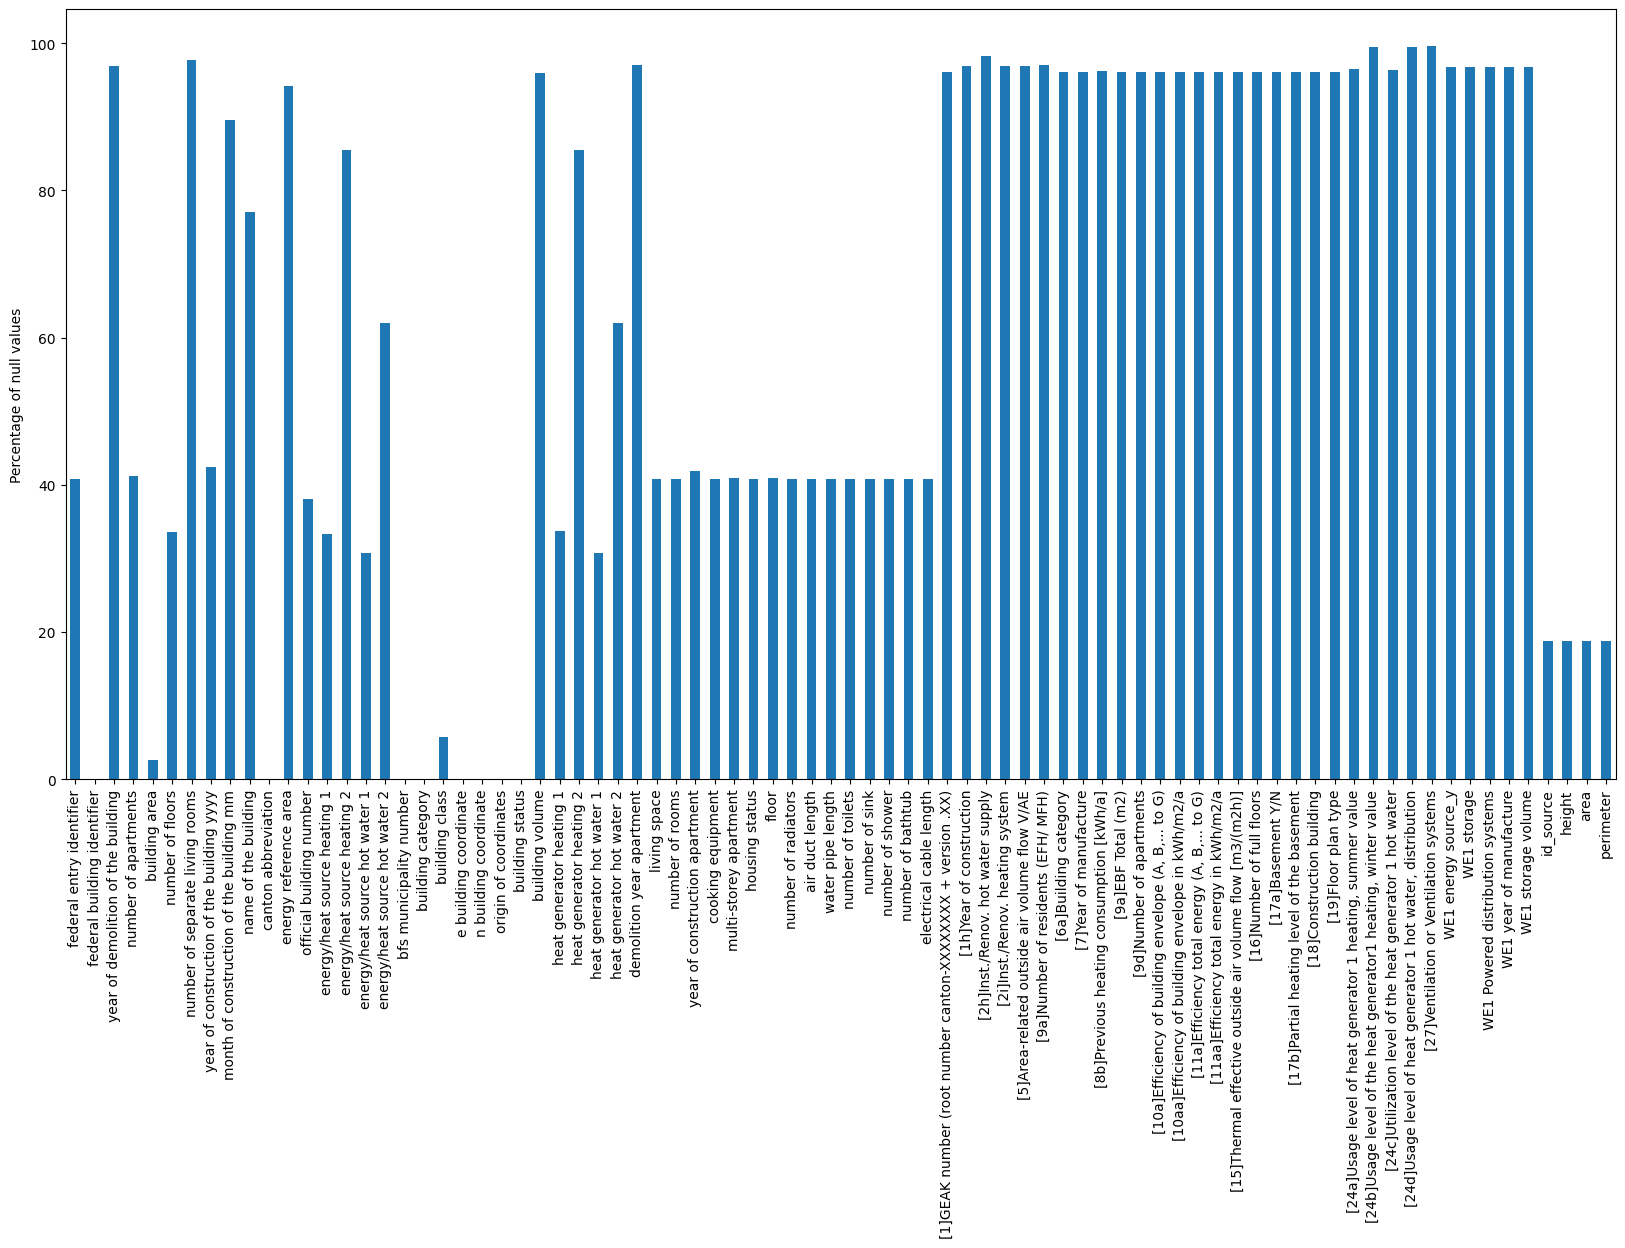

In [39]:
# check percentage of null values in each column in bar chart
null_percentages = df.isnull().sum() / len(df) * 100
null_percentages.plot(kind='bar', figsize=(20, 10))
plt.ylabel('Percentage of null values')

plt.show()

In [40]:
# import pandas as pd

# Assuming your DataFrame is called 'df'
cols_to_keep = ['federal building identifier', 'canton abbreviation', 'building status',
                'e building coordinate', 'n building coordinate', 'origin of coordinates',
                'building category', 'building area', 'building class','area', 'perimeter', 'height',
                'energy/heat source hot water 1', 'heat generator hot water 1',
                'energy/heat source heating 1', 'heat generator heating 1', 'number of floors',
                'official building number', 'living space', 'number of rooms', 'cooking equipment',
                'multi-storey apartment', 'floor', 'number of radiators', 'air duct length',
                'water pipe length', 'number of toilets', 'number of sink', 'number of shower',
                'number of bathtub', 'electrical cable length', 'number of apartments',
                'year of construction of the building yyyy', 'energy/heat source hot water 2',
                'heat generator hot water 2', 'energy/heat source heating 2', 'heat generator heating 2',
                'energy reference area', 'building volume', '[18]Construction building',
                '[19]Floor plan type', '[2i]Inst./Renov. heating system', '[5]Area-related outside air volume flow V/AE',
                'year of demolition of the building', '[9a]Number of residents (EFH/ MFH)',
                '[2h]Inst./Renov. hot water supply']

# Create a new DataFrame with only the desired columns
df_subset = df[cols_to_keep]
df_subset

,federal building identifier,canton abbreviation,building status,e building coordinate,n building coordinate,origin of coordinates,building category,building area,building class,area,perimeter,height,energy/heat source hot water 1,heat generator hot water 1,energy/heat source heating 1,heat generator heating 1,number of floors,official building number,living space,number of rooms,cooking equipment,multi-storey apartment,floor,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length,number of apartments,year of construction of the building yyyy,energy/heat source hot water 2,heat generator hot water 2,energy/heat source heating 2,heat generator heating 2,energy reference area,building volume,[18]Construction building,[19]Floor plan type,[2i]Inst./Renov. heating system,[5]Area-related outside air volume flow V/AE,year of demolition of the building,[9a]Number of residents (EFH/ MFH),[2h]Inst./Renov. hot water supply
0,11513432,ZH,1004,2679647.268,1237500.347,901.0,1020.0,166.0,1121.0,161.388685,53.999959,6.73,7530.0,7630.0,7530.0,7430.0,3.0,1199,220.0,8.0,2.0,0.0,3102.0,12.0,43.692096,129.161366,4.0,4.0,4.0,4.0,1092.302393,2.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11513433,ZH,1004,2680635.900,1236936.229,901.0,1020.0,90.0,1110.0,78.432286,38.718131,9.31,7560.0,7650.0,7530.0,7430.0,2.0,1198,130.0,4.0,1.0,1.0,3100.0,7.0,22.803509,68.410526,2.0,2.0,2.0,2.0,570.087713,1.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11517090,ZH,1004,2679016.828,1235828.156,901.0,1020.0,72.0,1110.0,200.752267,59.348525,8.11,7530.0,7630.0,7530.0,7431.0,3.0,1017,200.0,6.0,1.0,1.0,3100.0,11.0,42.426407,113.137085,3.0,3.0,3.0,3.0,1060.660172,1.0,1993.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1600000,ZH,1004,2679677.869,1237453.256,901.0,1020.0,165.0,1110.0,161.715786,54.993635,12.03,7530.0,7630.0,7530.0,7430.0,3.0,164,430.0,14.0,2.0,1.0,3100.0,24.0,108.873263,275.443622,7.0,7.0,7.0,7.0,2721.831570,1.0,1845.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1600001,ZH,1004,2679692.997,1237491.284,901.0,1030.0,313.0,1110.0,313.931512,90.550116,5.29,7530.0,7630.0,7530.0,7436.0,2.0,154,90.0,5.0,1.0,0.0,3101.0,6.0,23.717082,66.407831,2.0,2.0,2.0,2.0,592.927061,1.0,1900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171849,984011,JU,1004,2574820.204,1259516.667,901.0,1020.0,105.0,1110.0,96.981815,53.224104,6.28,7560.0,7650.0,7530.0,7430.0,1.0,NaN,60.0,3.0,1.0,0.0,3100.0,4.0,11.618950,38.729833,1.0,1.0,1.0,1.0,290.473751,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3171850,984012,JU,1004,2574876.850,1259399.577,901.0,1020.0,95.0,1110.0,88.832799,39.458632,7.26,7560.0,7650.0,7530.0,7436.0,1.0,NaN,80.0,4.0,1.0,0.0,3100.0,5.0,17.888544,53.665631,2.0,2.0,2.0,2.0,447.213595,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3171851,984013,JU,1004,2574881.706,1259352.651,901.0,1030.0,116.0,1110.0,134.378219,46.947398,7.89,7560.0,7650.0,7560.0,7450.0,2.0,NaN,90.0,3.0,1.0,1.0,3100.0,5.0,14.230249,47.434165,1.0,1.0,1.0,1.0,355.756237,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3171852,984014,JU,1004,2574841.933,1259366.178,901.0,1020.0,106.0,1110.0,72.522433,35.282097,7.36,7530.0,7630.0,7530.0,7430.0,2.0,NaN,80.0,3.0,1.0,1.0,3100.0,5.0,13.416408,44.721360,1.0,1.0,1.0,1.0,335.410197,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# export the DataFrame to a txt file
df_subset.to_csv('full_data_20241025_selected.txt', index=False)